In [1]:
from Scripts.Random_forest_nested import *
import matplotlib.pyplot as plt
import pickle 

In [2]:
df = pd.read_excel('../SImulated_data/Clinical_synthetic.xlsx', index_col=0)
X,y=df.loc[:,['scaled_nox','scaled_no2','scaled_formaldehyd','scaled_acetone','scaled_acetald',
    'scaled_bc', 'scaled_PM25','no2_street', 'nox_street', 'pm25_street', 'gestational_age',
       'genetic_risk_score_asthma']],df.asthma_0_7yrs

In [3]:
df.columns

Index(['household', 'scale_formaldehyd', 'scale_acetald', 'scale_vocs',
       'scaled_nox', 'scaled_no2', 'scaled_formaldehyd', 'scaled_acetone',
       'scaled_acetald', 'scaled_vocs', 'constrution_year', 'Area',
       'floor_level', 'powerplant', 'road', 'motorway', 'forest', 'coastline',
       'airport', 'farmland', 'industrial', 'carpet', 'cookerhood', 'passive',
       'gastove', 'fireplace', 'corrected_week', 'scaled_bc', 'scaled_PM25',
       'no2_regional', 'nox_regional', 'pm25_regional', 'no2_street',
       'nox_street', 'pm25_street', 'bmi_6_yrs', 'gestational_age',
       'mother's_education_1yr', 'lrti_1y', 'urti_1y', 'rti_1y', 'fever_1y',
       'gi_1y', 'any_1y', 'lrti_3yr', 'urti_3yr', 'rti_3yr', 'fever_3yr',
       'gi_3yr', 'any_3yr', 'genetic_risk_score_asthma', 'PCA1', 'PCA2',
       'asthma_0_7yrs', 'verificeret_18y', 'verificeret_12y', 'crp_6mo',
       'il_1β_6mo', 'il_8_6mo', 'il_6_6mo', 'tnf_α_6mo'],
      dtype='str')

In [4]:
list_parameters=["$NO_x$","$NO_2$","Formaldehyd","Acetone","Acetald","Black Carbon","$PM_{2.5}$","Street $NO_2$","Street $NO_x$","Street $PM_{2.5}$","Gestational age","Asthma risk score"]

In [5]:
replace_dict=dict(zip(X.columns,list_parameters))
X=X.rename(columns=replace_dict)

In [6]:
replace_dict

{'scaled_nox': '$NO_x$',
 'scaled_no2': '$NO_2$',
 'scaled_formaldehyd': 'Formaldehyd',
 'scaled_acetone': 'Acetone',
 'scaled_acetald': 'Acetald',
 'scaled_bc': 'Black Carbon',
 'scaled_PM25': '$PM_{2.5}$',
 'no2_street': 'Street $NO_2$',
 'nox_street': 'Street $NO_x$',
 'pm25_street': 'Street $PM_{2.5}$',
 'gestational_age': 'Gestational age',
 'genetic_risk_score_asthma': 'Asthma risk score'}

In [7]:
param_distributions = {
    'n_estimators':           [300],
    'max_depth':              randint(2, 6),
    'min_samples_leaf':       randint(10, 30),
    'max_features':           [0.4, 0.5, 0.6, 'sqrt'],
    'max_samples':            [0.5, 0.6, 0.7, 0.8],
    # class_weight removed
}
dataframe =nested_cross_calibrated_rf(
    X, y,
    Number_CV=2,
    number_split=3,
    n_neighbors_imputer=25,
    param_distributions=param_distributions,
    calibration_method="isotonic")



Fold 1/6  AUC=0.514  BSS=-0.010  ICI=0.076
Fold 2/6  AUC=0.479  BSS=-0.003  ICI=0.042
Fold 3/6  AUC=0.582  BSS=+0.019  ICI=0.041
Fold 4/6  AUC=0.529  BSS=-0.009  ICI=0.052
Fold 5/6  AUC=0.565  BSS=-0.007  ICI=0.026
Fold 6/6  AUC=0.484  BSS=-0.024  ICI=0.047


In [8]:
with open("../Performence/results_rf_7y.pkl", "wb") as f:
    pickle.dump(dataframe, f)

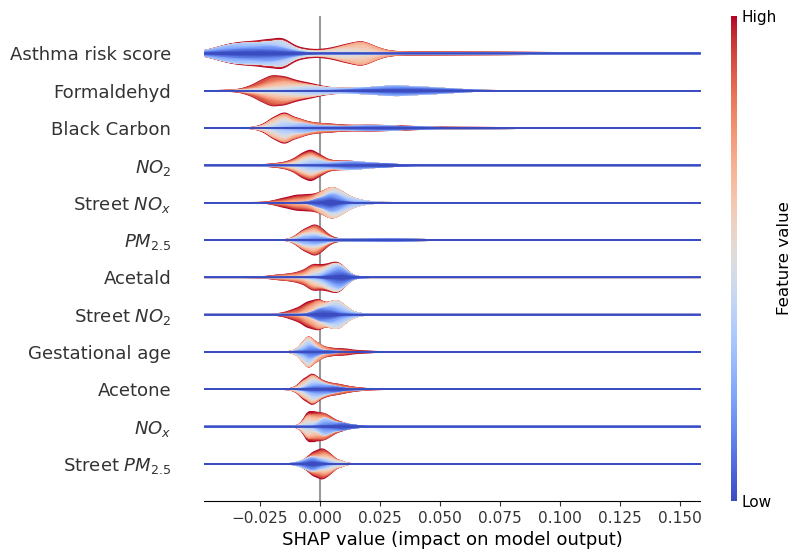

In [9]:

fig=shap.plots.violin(dataframe['shap_values_oof'],X ,plot_type="layered_violin",show=False)
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica", "Arial", "DejaVu Sans"],
})
# increase pad to push title further away


plt.savefig('../Plots/shap_7.png',dpi=300,bbox_inches='tight')
